# **Simulation Albatross 2026**

Team: TU Wien Space Team \
Project: Lamarr \
Rocket: Albatross


## Installs

In this section all needed libraries are installed and the needed classes imported

In [9]:
!python.exe -m pip install --upgrade pip

In [1]:
%pip install rocketpy==1.12.1

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
%pip install CoolProp

In [5]:
from rocketpy import Environment, Rocket, Flight, SolidMotor, NoseCone, Tail, Parachute, FreeFormFins
import numpy as np
from math import pi

## Configuration

The length unit chosen here is millimeters to keep the values more readable. If necessary, values should be converted accordingly.

In [14]:
# Rocket configuration data
#
env_config = {
    "date" : (2026, 4, 9, 17, 00, 00),    # yyyy, mm, dd, hh, mm, ss    # preset
    "latitude" : 48.235664,               # Launch latitude             # preset
    "longitude" : 13.270953,              # Launch longitude            # preset
    "max_height" : 2000,                  # m                           # preset    
    "timezone" : "Europe/Rome"            # GMT+1                       # preset
}

motor_config = {
    "name": "K700W",
    "total_mass": 2035,                   # g       # preset
    "propellant_mass": 1303,              # g       # preset
    "diameter": 54,                       # g       # preset
    "length": 568,                        # mm      # preset
    "burn_time": 3.5                      # s       # preset
}

rocket_config = {
    "total_weight" : 17770,               # g       # weighed dry mass
    "total_length" : 3765,                # mm      # measured
    "total_CG" : 1821,                    # mm      # measured      # FROM TIP!
    "moment_of_intertia_Z" : 0.036849,    # kg*m^2  # calculated
    "moment_of_intertia_XY" : 16.535531,  # kg*m^2  # calculated
    "nosecone" : {
        "length" : 645,                   # mm      # measured
        "kind" : "lv haack"
    },
    "railbuttons" : {
        "upper" : 1400,                   # mm      # measured      # FROM BOTTOM!
        "lower" : 320                     # mm      # measured      # FROM BOTTOM!
    },
    "tailcone" : {
        "diameter" : 107,                 # mm      # measured
        "length" : 280,                   # mm      # measured
        "cylindrical_height" : 35         # mm      # measured
    },
    "rocket" : {
        "thickness" : 1.4,                # mm      # measured
        "diameter" : 132.8                # mm      # measured
    },
    "fins" : {
        "name" : "Biconvex-Freeform",
        "amount" : 4,
        "position" : 250,                 # mm      # measured
        "shape_points" : ((0,0.012),
                          (0.250,0),
                          (0.250, 0.110),
                          (0.195, 0.110),
                          (0,0.012))          # m       # measured
    },
    "parachutes" : {
        "main" : {
            "cd_s" : 6.911503837897546,                     # calculated
            "trigger" : 250,              # m               # preset
            "sampling_rate" : 105,        # hz              # preset
            "lag" : 5,                    # s               # measured
            "noise" : (0, 8.3, 0.5)       # (pa, pa, pa)    # preset
        },
        "drogue" : {
            "cd_s" : 0.5336875,
            "trigger" : "apogee",         # m               # preset
            "sampling_rate" : 105,        # hz              # preset
            "lag" : 1,                    # s               # measured
            "noise" : (0, 8.3, 0.5)       # (pa, pa, pa)    # preset
        }
    }
}
flight_config = {
    "rail_length" : 7,                    # m       #Preset
    "inclination" : 86,                   # °       #Preset
    "heading" : 0,                      # °       #Preset
    "terminate_on_apogee" : False
}

## Environments Initialization




In this section the environments are initialized.

Fetching elevation from open-elevation.com for lat=48.235664, lon=13.270953...
Elevation received: 376.0 m

Gravity Details

Acceleration of gravity at surface level:    9.7791 m/s²
Acceleration of gravity at  13.587 km (ASL): 9.7385 m/s²


Launch Site Details

Launch Date: 2026-04-09 15:00:00 UTC | 2026-04-09 17:00:00 Europe/Rome
Launch Site Latitude: 48.23566°
Launch Site Longitude: 13.27095°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 166021.44 W|E    0.00 N
Launch Site UTM zone: 31N
Launch Site Surface Elevation: 382.0 m


Atmospheric Model Details

Atmospheric Model Type: Windy
Windy Maximum Height: 13.587 km

Surface Atmospheric Conditions

Surface Wind Speed: 2.04 m/s
Surface Wind Direction: 81.93°
Surface Wind Heading: 261.93°
Surface Pressure: 975.54 hPa
Surface Temperature: 285.13 K
Surface Air Density: 1.192 kg/m³
Surface Speed of Sound: 338.51 m/s


Earth Model Details

Earth Radius at Launch site: 6378.14 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75

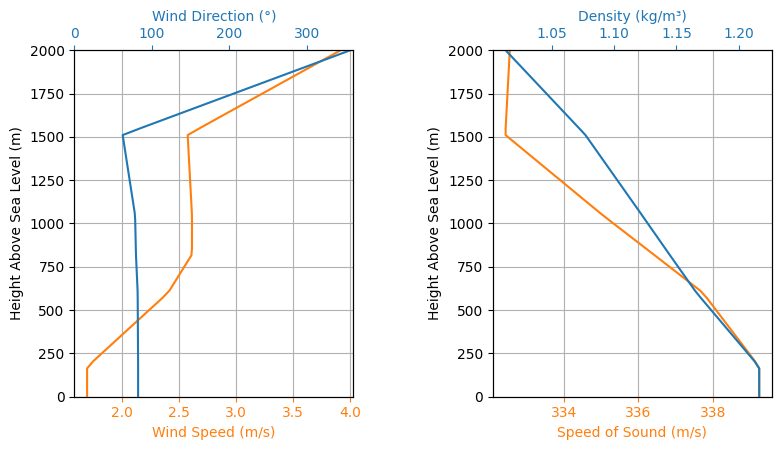

In [7]:
latitude    = env_config["latitude"]
longitude   = env_config["longitude"]
timezone    = env_config["timezone"]
date        = env_config["date"]
max_height  = env_config["max_height"]

#Environment based on Forecast data for the EuRoC 2024
envForecast = Environment(max_expected_height = max_height)
envForecast.set_location(latitude = latitude, longitude = longitude)
envForecast.set_elevation("Open-Elevation") # 351m
envForecast.set_date(date, timezone = timezone)
envForecast.set_atmospheric_model(type = "Windy", file = "ECMWF")
envForecast.info()

## Simulation

### Engine



Nozzle Details
Nozzle Radius: 0.027 m
Nozzle Throat Radius: 0.0135 m

Grain Details
Number of Grains: 1
Grain Spacing: 0 m
Grain Density: 1001.6561894971871 kg/m3
Grain Outer Radius: 0.027 m
Grain Inner Radius: 0 m
Grain Height: 0.568 m
Grain Volume: 0.001 m3
Grain Mass: 1.303 kg

Motor Details
Total Burning Time: 3.5 s
Total Propellant Mass: 1.303 kg
Structural Mass Ratio: 0.360
Average Propellant Exhaust Velocity: 1751.895 m/s
Average Thrust: 652.205 N
Maximum Thrust: 1029.337 N at 0.632 s after ignition.
Total Impulse: 2282.719 Ns



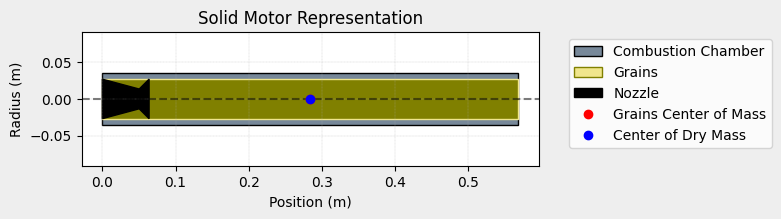

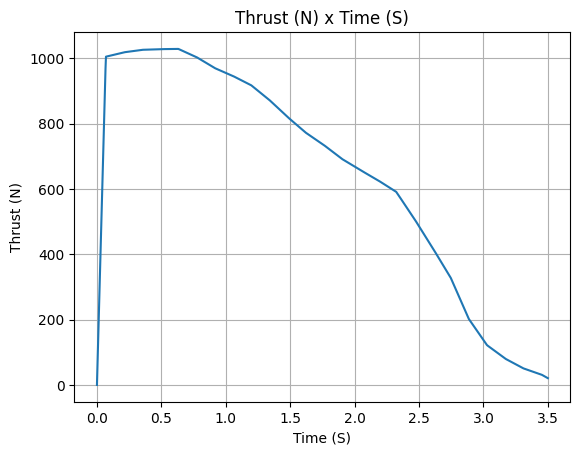

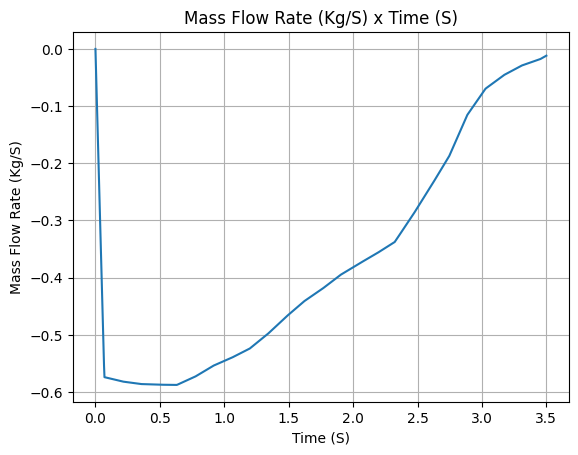

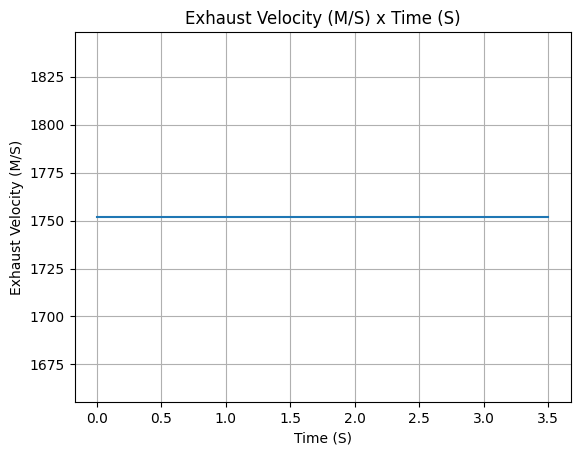

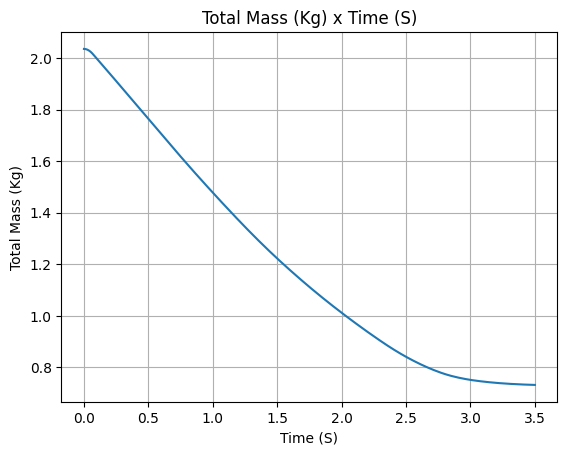

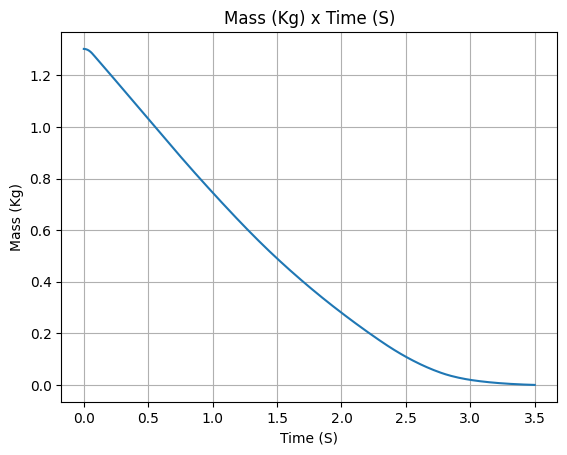

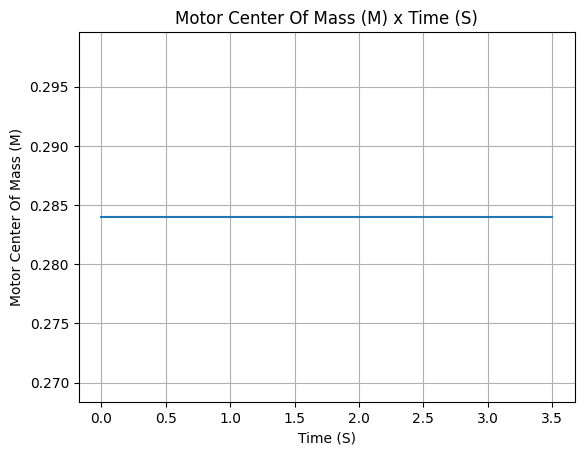

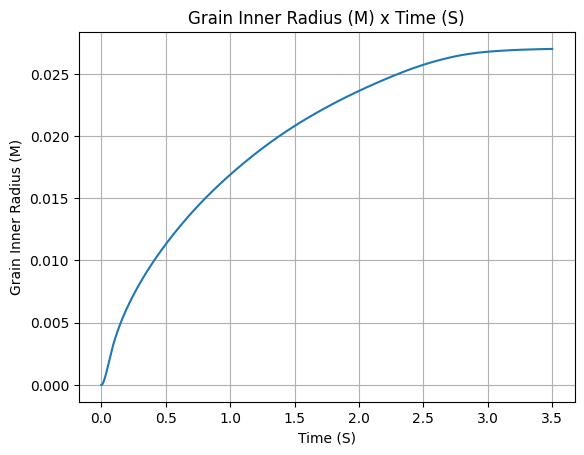

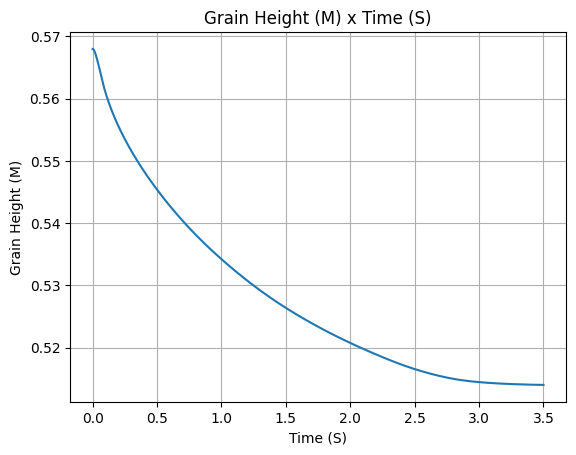

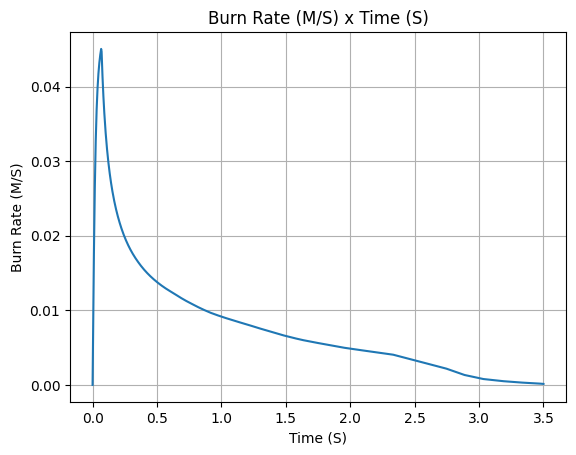

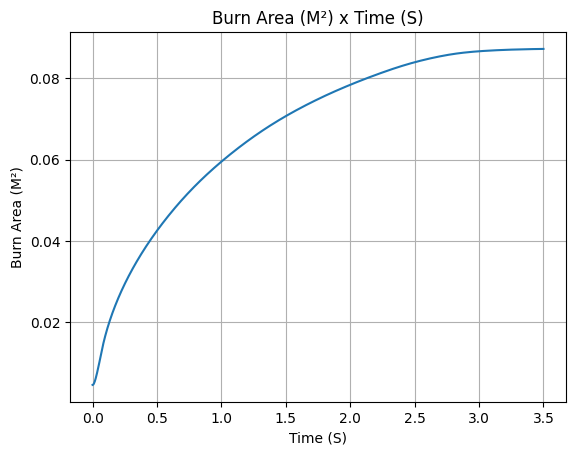

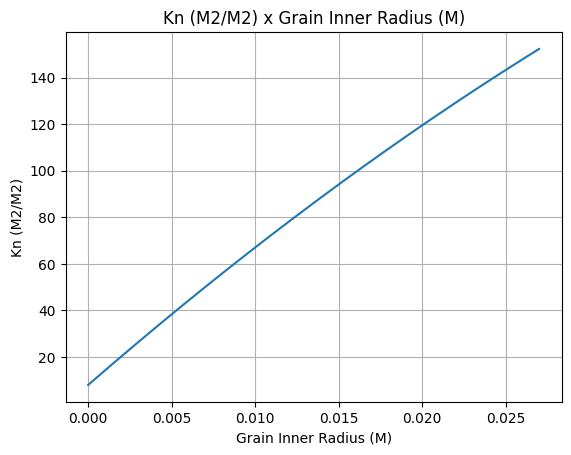

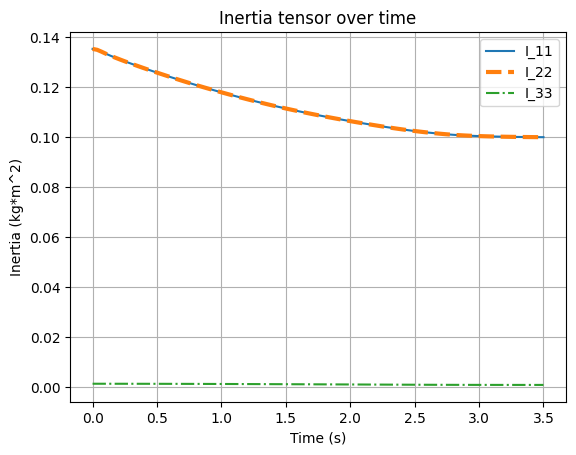

In [8]:
motor_total_mass        = motor_config["total_mass"] /1000            #kg
motor_propellant_mass   = motor_config["propellant_mass"] /1000       #kg
motor_radius            = motor_config["diameter"] /1000 /2           #kg
motor_length            = motor_config["length"]  /1000               #m
motor_volume            = pi * (motor_radius ** 2) * motor_length     #m³
motor_grain_density     = motor_propellant_mass/motor_volume          #kg/m³
motor_burn_time         = motor_config["burn_time"]

k700w = SolidMotor(
  thrust_source                   = "AeroTech_K700W.eng",
  dry_mass                        = motor_total_mass - motor_propellant_mass,
  dry_inertia                     = (0.1, 0.1, 0.001),                        #kg*m²   #guess / not so relevant
  nozzle_radius                   = motor_radius,
  grain_number                    = 1,
  grain_density                   = motor_grain_density,
  grain_outer_radius              = motor_radius,
  grain_initial_inner_radius      = 0,
  grain_initial_height            = motor_length,
  grain_separation                = 0,
  grains_center_of_mass_position  = motor_length / 2,
  center_of_dry_mass_position     = motor_length / 2,
  nozzle_position                 = 0,
  burn_time                       = motor_burn_time,
  throat_radius                   = motor_radius / 2,
  coordinate_system_orientation   = "nozzle_to_combustion_chamber",
)
k700w.all_info()

### Rocket components

c:\Users\diego\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rocketpy\rocket\aero_surface\fins\free_form_fins.py:143: UserWarning: Jagged fin shape detected. This may cause small inaccuracies center of pressure and pitch moment calculations.
  warnings.warn(


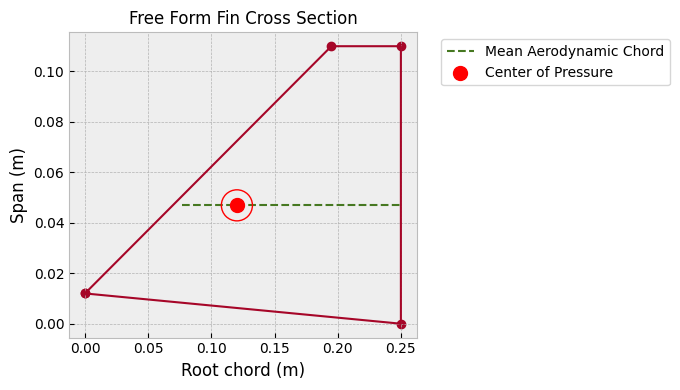

In [15]:
#rocket
rocket_length     = rocket_config["total_length"]         / 1000
rocket_diameter   = rocket_config["rocket"]["diameter"]   / 1000
rocket_thickness  = rocket_config["rocket"]["thickness"]  / 1000


nosecone_length = (rocket_config["nosecone"]["length"]-80)    / 1000   # -80 mm to adjust for cylindrical section
nosecone_kind = rocket_config["nosecone"]["kind"]

nose_cone = NoseCone(
    length = nosecone_length,
    base_radius = rocket_diameter/2,
    kind = nosecone_kind
)

tailcone_cylindrical    = rocket_config["tailcone"]["cylindrical_height"] / 1000
tailcone_length         = rocket_config["tailcone"]["length"]             / 1000
tailcone_bottom_radius  = rocket_config["tailcone"]["diameter"]        /2 / 1000

tail = Tail(
    top_radius = rocket_diameter /2,
    bottom_radius = tailcone_bottom_radius,
    length = tailcone_length,
    rocket_radius = rocket_diameter/2
)

fin_amount        = rocket_config["fins"]["amount"]
fin_shape_points  = rocket_config["fins"]["shape_points"]
fin_name          = rocket_config["fins"]["name"]

fin_set = FreeFormFins(
   n = fin_amount,
   shape_points = fin_shape_points,
   rocket_radius=tailcone_bottom_radius,
   name = fin_name
)
fin_set.draw()

#fin_set = TrapezoidalFins(
#      n             = fin_amount,
#      root_chord    = 0.250,
#      tip_chord     = 0.050,
#      span          = 0.108,
#      sweep_length  = 0.195,
#      rocket_radius = tailcone_bottom_radius,
#      name          = "Trapezoidal"
#)
#fin_set.draw()

main_cd_s               = rocket_config["parachutes"]["main"]["cd_s"]
main_trigger            = rocket_config["parachutes"]["main"]["trigger"]
main_sampling_rate      = rocket_config["parachutes"]["main"]["sampling_rate"]
main_lag                = rocket_config["parachutes"]["main"]["lag"]
main_noise              = rocket_config["parachutes"]["main"]["noise"]

drogue_cd_s             = rocket_config["parachutes"]["drogue"]["cd_s"]
drogue_trigger          = rocket_config["parachutes"]["drogue"]["trigger"]
drogue_sampling_rate    = rocket_config["parachutes"]["drogue"]["sampling_rate"]
drogue_lag              = rocket_config["parachutes"]["drogue"]["lag"]
drogue_noise            = rocket_config["parachutes"]["drogue"]["noise"]

parachutes = {}

parachutes[0] = Parachute(
    name = "main",
    cd_s = main_cd_s,
    trigger = main_trigger,
    sampling_rate = main_sampling_rate,
    lag = main_lag,
    noise = main_noise
)

parachutes[1] = Parachute(
    name = "drogue",
    cd_s = drogue_cd_s,
    trigger = drogue_trigger,
    sampling_rate = drogue_sampling_rate,
    lag = drogue_lag,
    noise = drogue_noise
)


### ALBATROSS


Inertia Details

Rocket Mass: 17.770 kg (without motor)
Rocket Dry Mass: 18.502 kg (with unloaded motor)
Rocket Loaded Mass: 19.805 kg
Rocket Structural Mass Ratio: 0.934
Rocket Inertia (with unloaded motor) 11: 18.573 kg*m2
Rocket Inertia (with unloaded motor) 22: 18.573 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.038 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0664 m
Rocket Frontal Area: 0.013851 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.066 m
Rocket Center of Dry Mass - Nozzle Exit: 1.878 m
Rocket Center of Dry Mass - Center of Propellant Mass: 1.594 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.105 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Biconvex-Freeform Lift Coefficient Derivative: 5.797/rad
Tail Lift

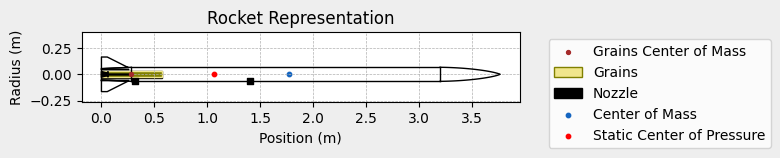


Mass Plots
----------------------------------------


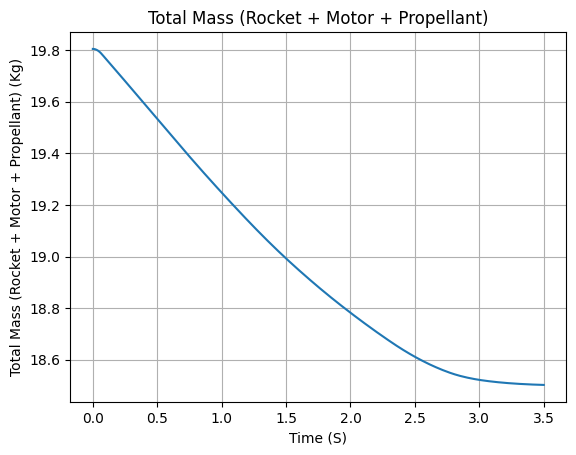

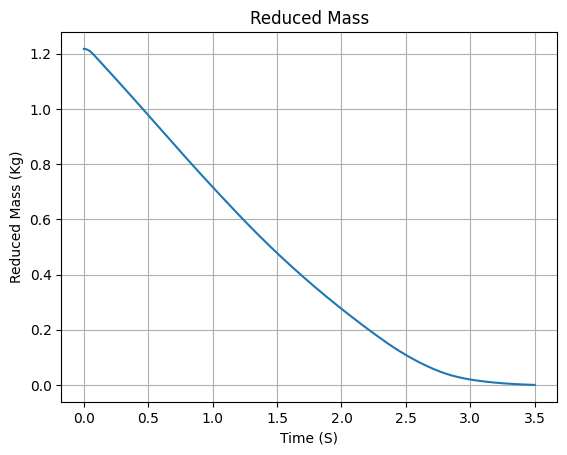


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


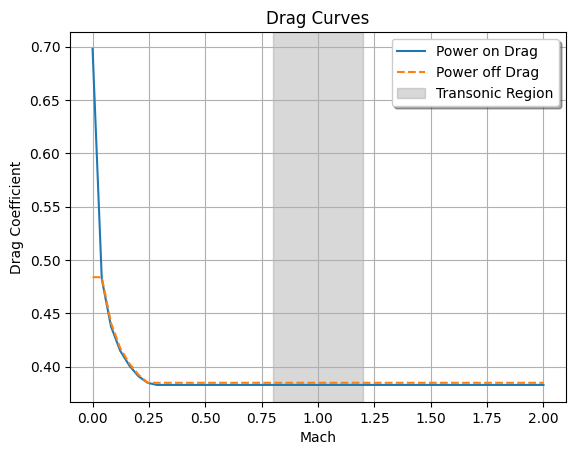


Stability Plots
--------------------


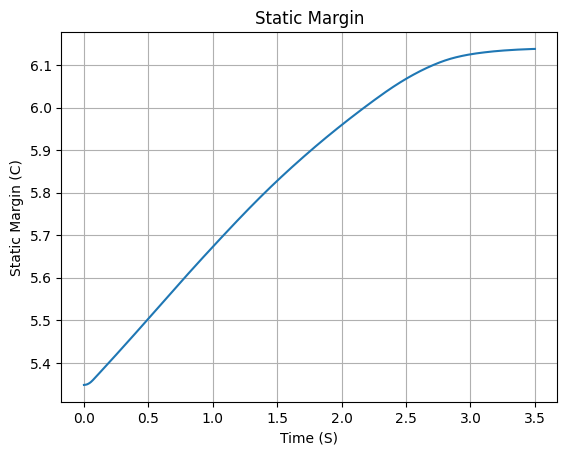

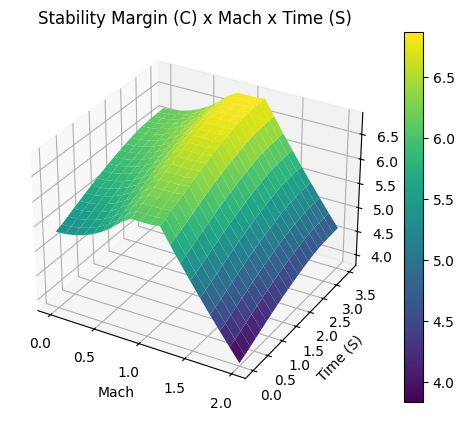


Thrust-to-Weight Plot
----------------------------------------


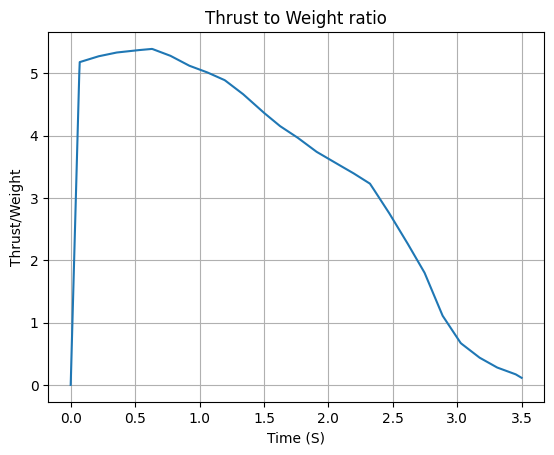

In [17]:
total_mass        = rocket_config["total_weight"] / 1000

#inertia
inertia_x_y   = rocket_config["moment_of_intertia_XY"]
inertia_z     = rocket_config["moment_of_intertia_Z"]

upper_railbutton_position   = rocket_config["railbuttons"]["upper"] / 1000
lower_railbutton_position   = rocket_config["railbuttons"]["lower"] / 1000
fin_position                = rocket_config["fins"]["position"]     / 1000

total_CG = rocket_config["total_CG"] / 1000

albatross = Rocket(
    radius = rocket_diameter /2,
    mass = total_mass,
    inertia = (inertia_x_y, inertia_x_y, inertia_z),
    power_off_drag = "./power_off_drag.csv",
    power_on_drag = "./power_on_drag.csv",
    center_of_mass_without_motor = rocket_length - total_CG,
    coordinate_system_orientation = "tail_to_nose"
)


albatross.add_motor(k700w, position = 0)


albatross.set_rail_buttons(upper_button_position = upper_railbutton_position, lower_button_position = lower_railbutton_position)

albatross.add_surfaces(surfaces = [nose_cone, fin_set, tail], positions = [rocket_length, fin_position, tailcone_length])

albatross.parachutes = list(parachutes.values())

albatross.all_info()

### Flight


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 382.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.923 | e1: -0.032 | e2: 0.013 | e3: 0.382
Euler Angles - Spin φ : 45.00° | Nutation θ: -4.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 5.348 c


Surface Wind Conditions

Frontal Surface Wind Speed: -0.29 m/s
Lateral Surface Wind Speed: 2.02 m/s


Launch Rail

Launch Rail Length: 7 m
Launch Rail Inclination: 86.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.558 s
Rail Departure Velocity: 21.809 m/s
Rail Departure Stability Margin: 5.528 c
Rail Departure Angle of Attack: 5.371°
Rail Departure Thrust-Weight Ratio: 5.381
Rail Departure Reynolds Number: 1.954e+05


Burn out State

Burn out time: 3.500 s
Altitude at burn out: 582.654 m (ASL) | 200.654 m (AGL)
Rocket speed at burn out: 82.771 m/s
Freestream velocity a

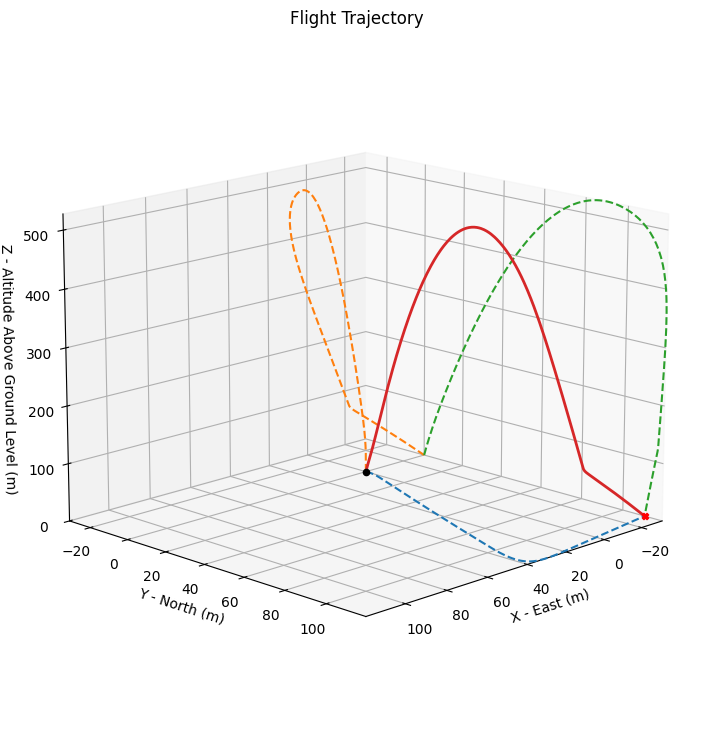



Trajectory Kinematic Plots



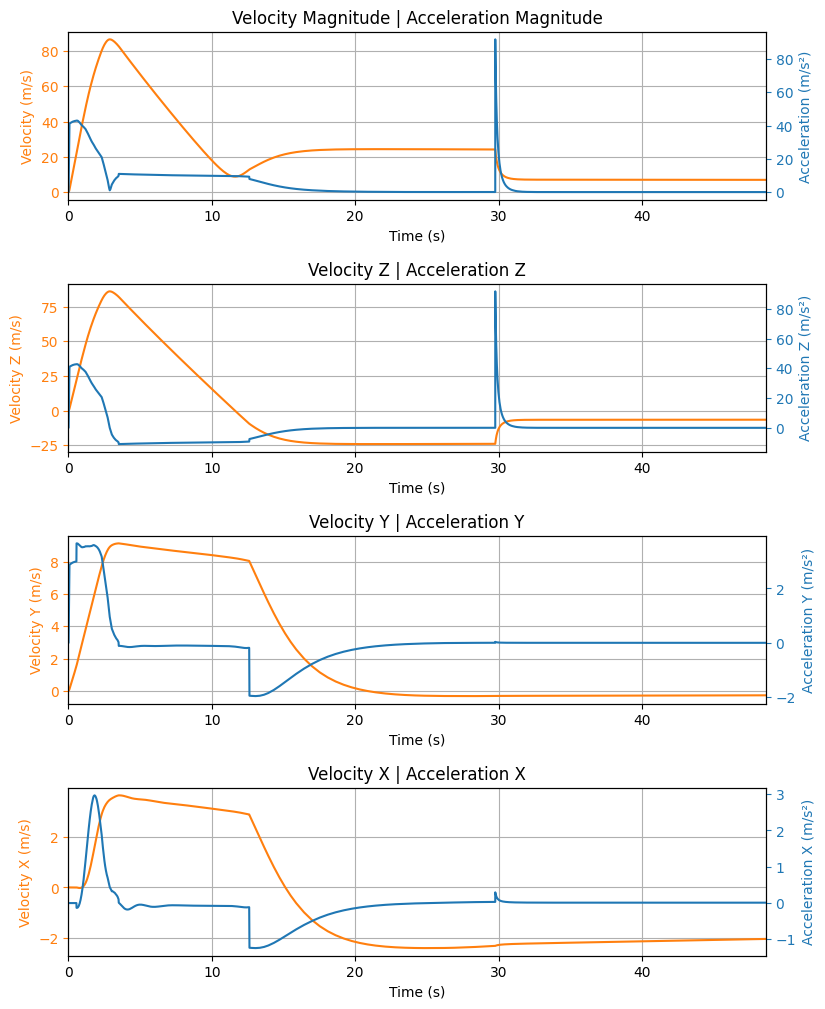



Angular Position Plots



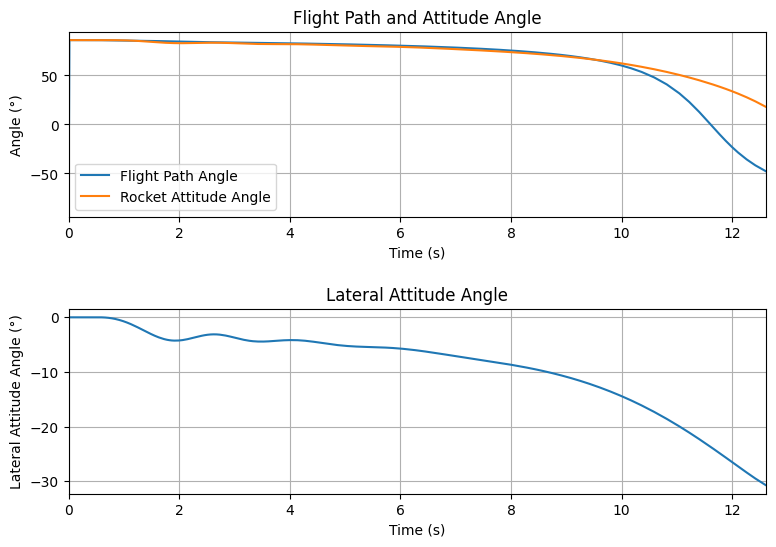



Path, Attitude and Lateral Attitude Angle plots



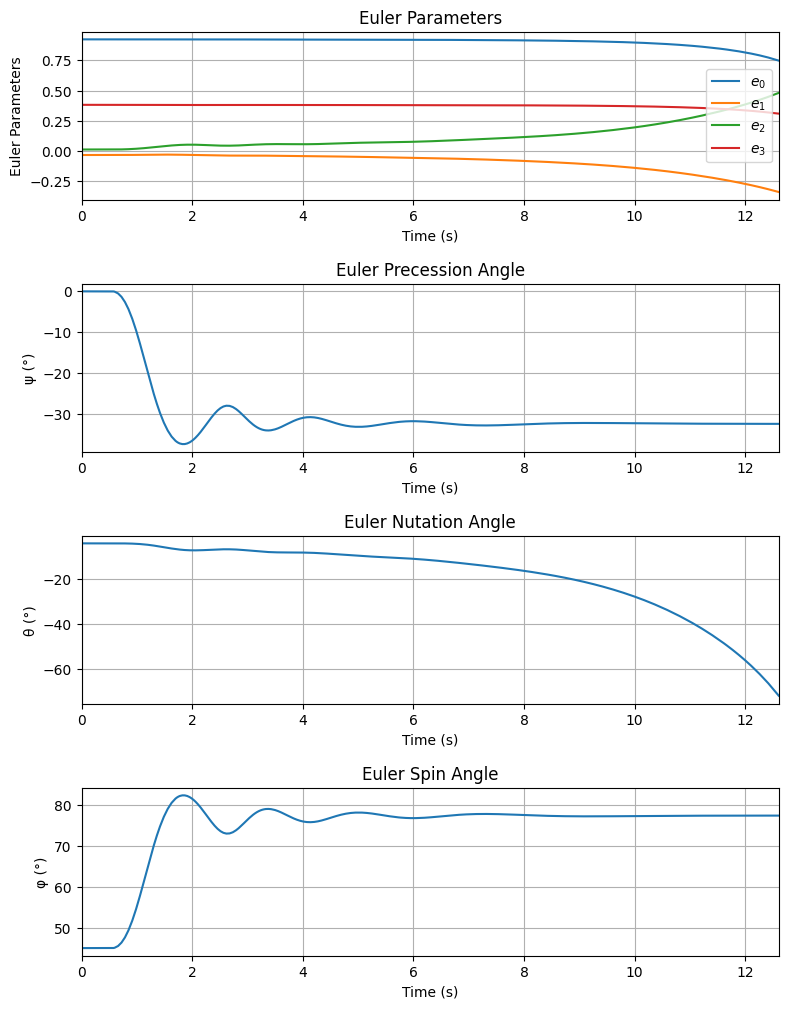



Trajectory Angular Velocity and Acceleration Plots



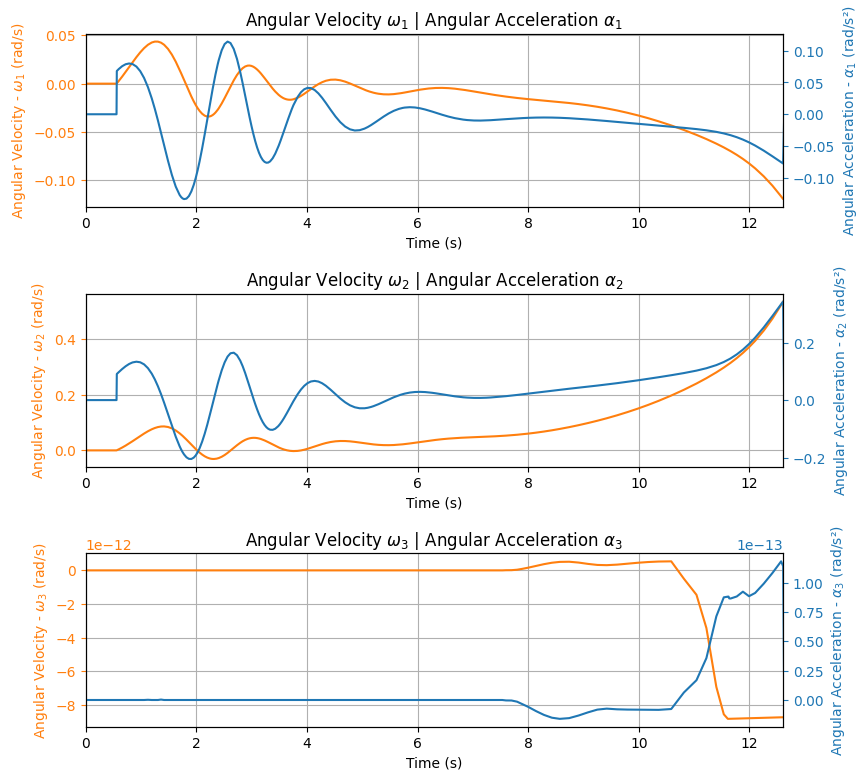



Aerodynamic Forces Plots



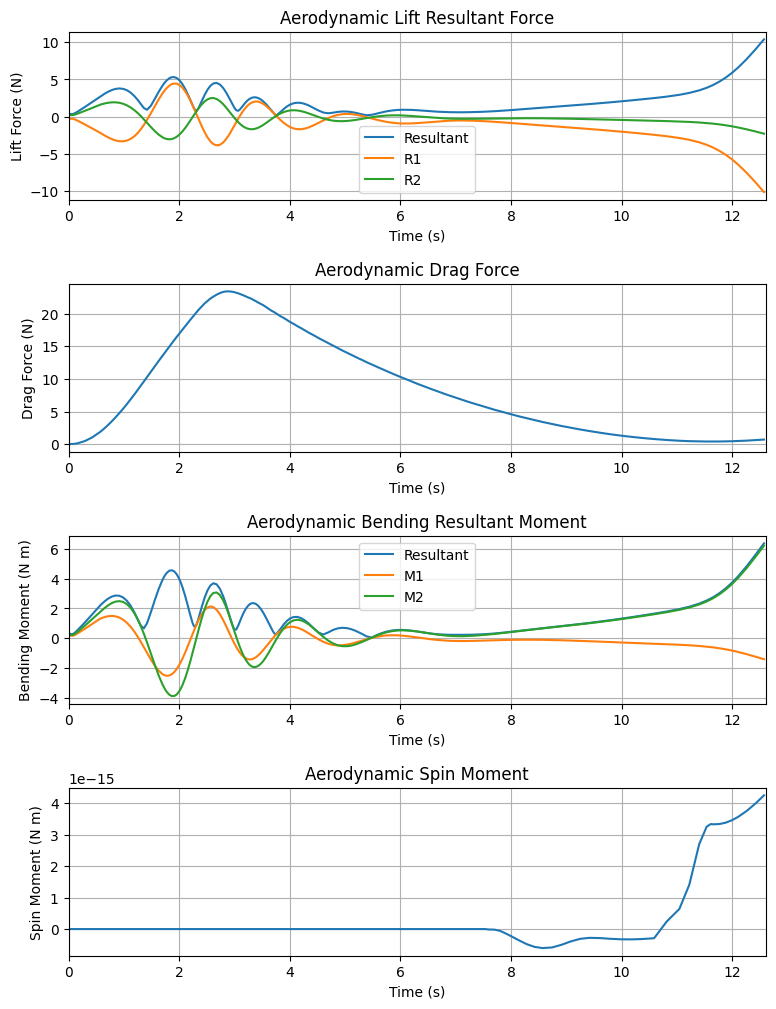



Rail Buttons Bending Moments Plots

Rail button height not defined. Skipping bending moment plots.


Rail Buttons Forces Plots



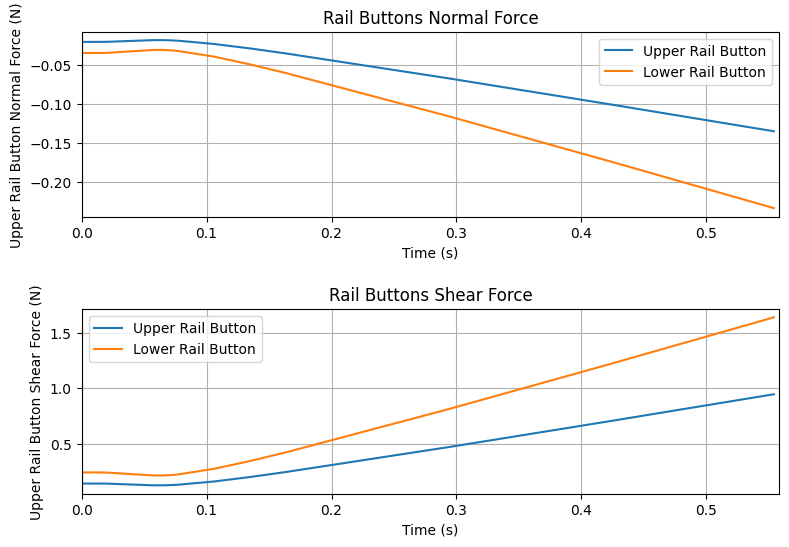



Trajectory Energy Plots



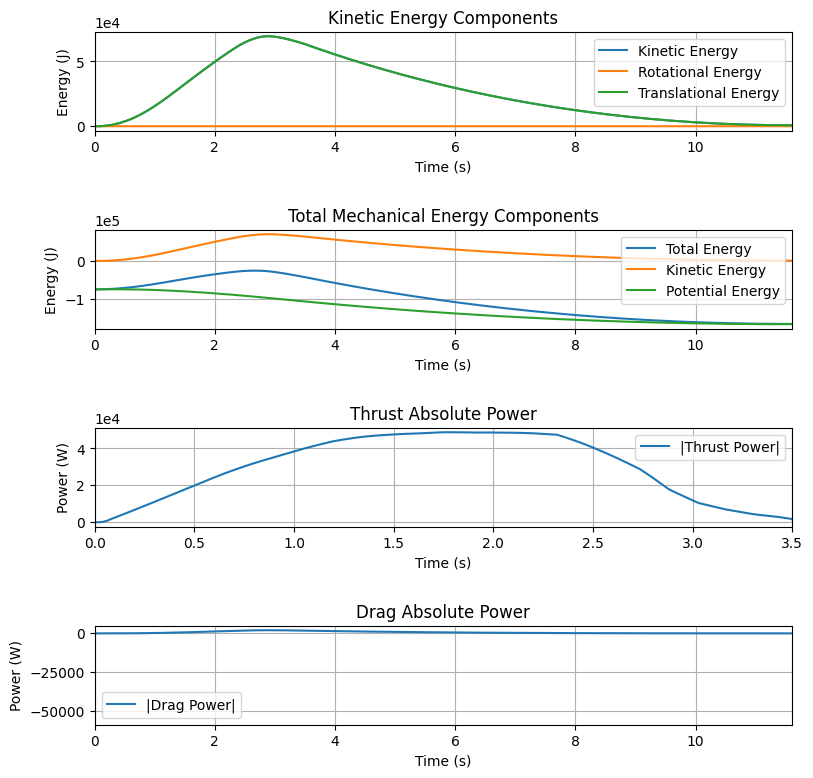



Trajectory Fluid Mechanics Plots



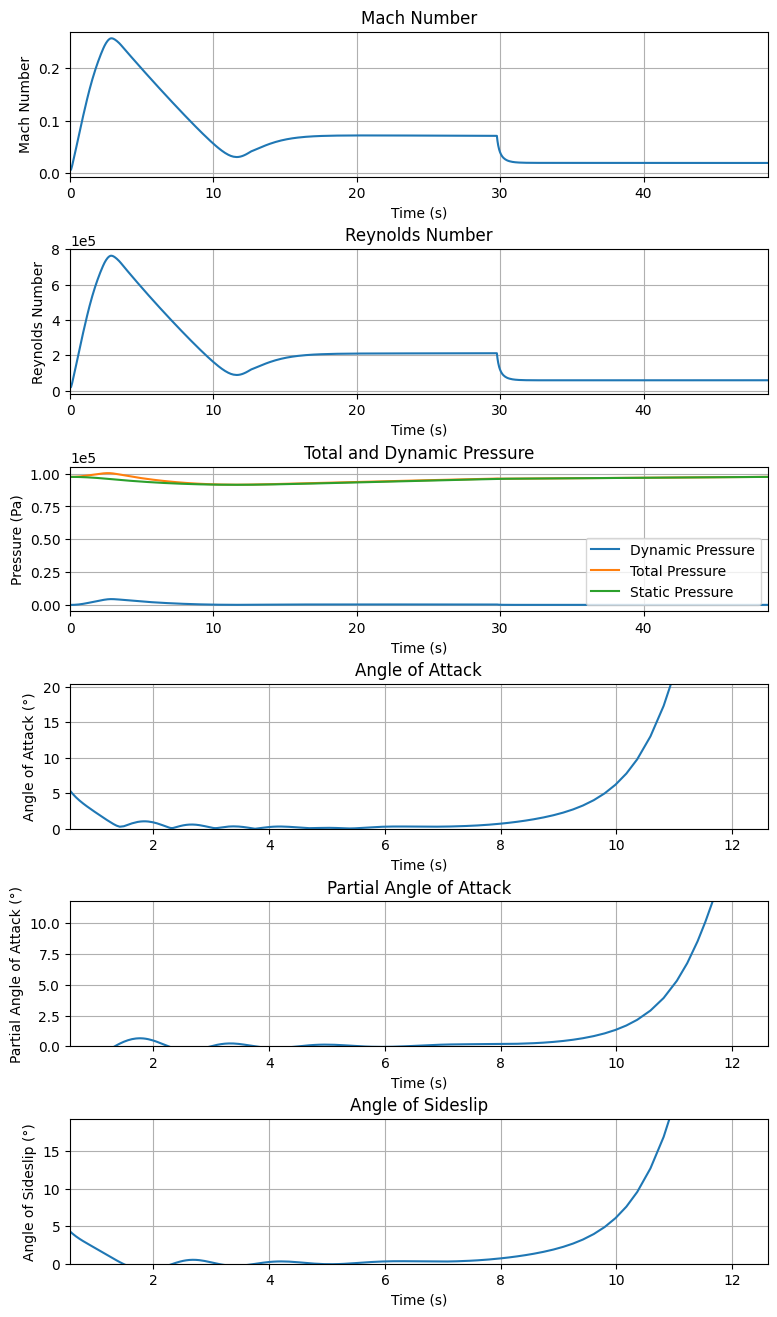



Trajectory Stability and Control Plots



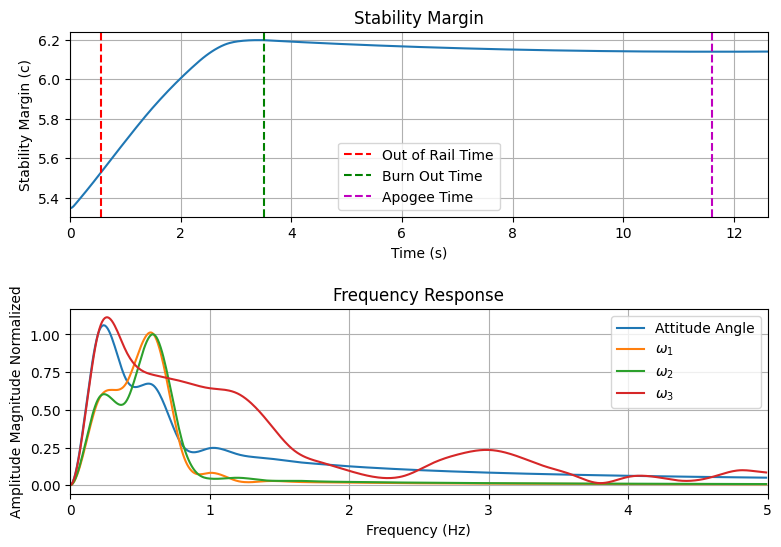



Rocket and Parachute Pressure Plots



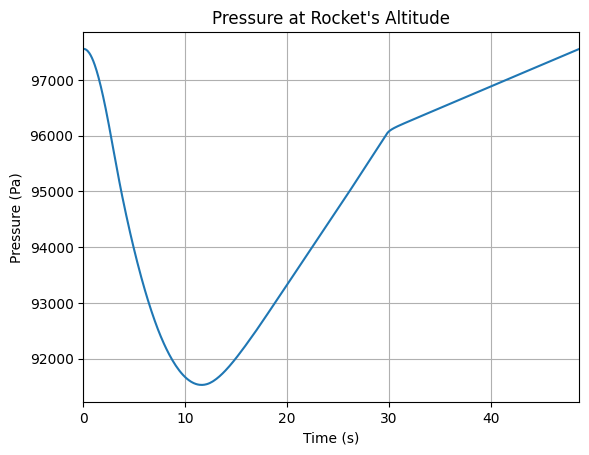


Parachute:  main


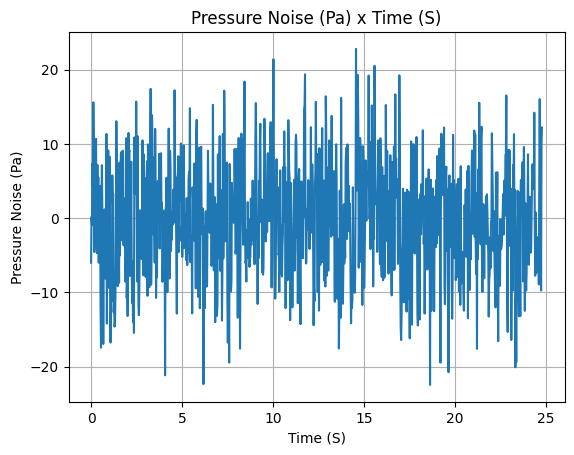

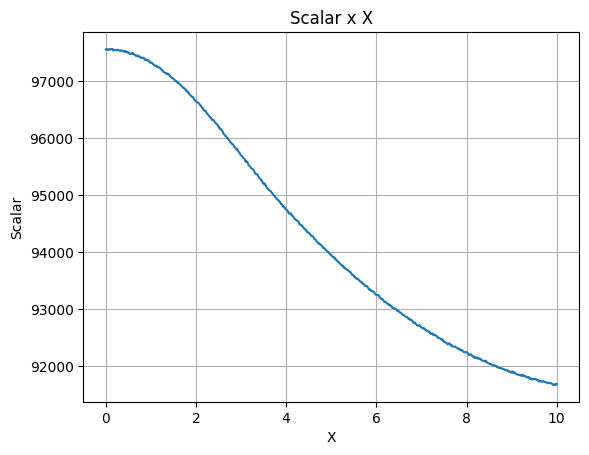

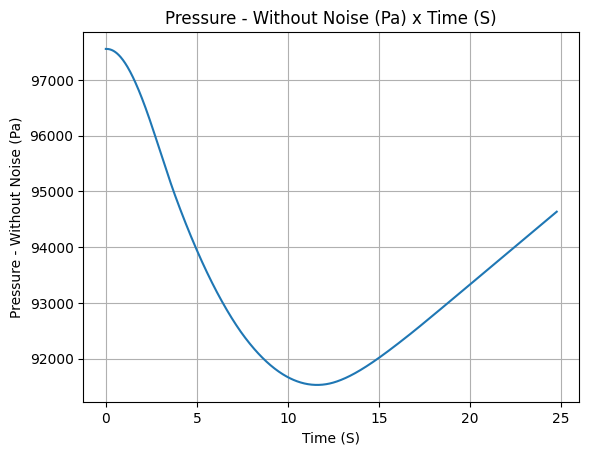


Parachute:  drogue


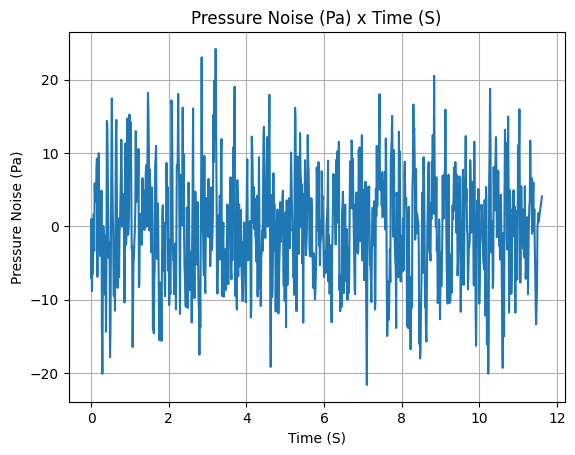

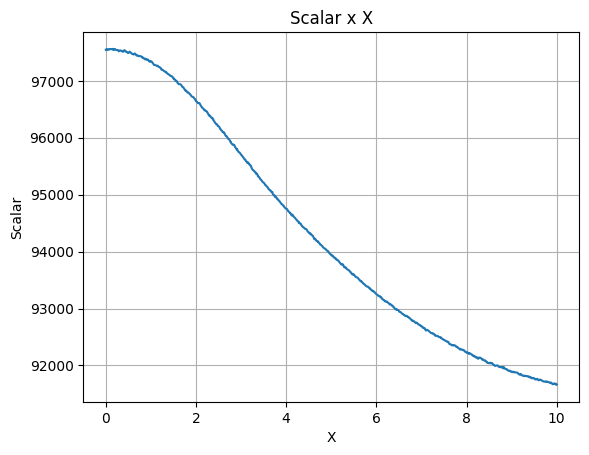

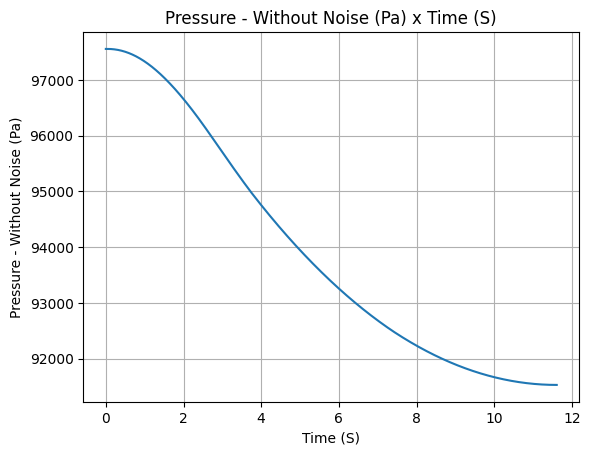

File  trajectory.kml  saved with success!


C:\Users\diego\AppData\Local\Temp\ipykernel_30968\3748174547.py:29: DeprecationWarning: Moved to FlightDataExporter.export_kml() and will be removed in v1.12.0. Use `rocketpy.simulation.flight_data_exporter.FlightDataExporter.export_kml` instead.
  flight_forecast.export_kml()


In [18]:
rail_length           = flight_config["rail_length"]
inclination           = flight_config["inclination"]
heading               = flight_config["heading"]
terminate_on_apogee   = flight_config["terminate_on_apogee"]

flight_forecast = Flight(
          rocket        = albatross,
          environment   = envForecast,
          rail_length   = rail_length,
          inclination   = inclination,
          heading       = heading,
          terminate_on_apogee = terminate_on_apogee,
          name          = "Forecast"
  )
#flight_forecast.prints.out_of_rail_conditions()
#flight_forecast.prints.apogee_conditions()
#flight_forecast.prints.impact_conditions()
#flight_forecast.prints.maximum_values()
#flight_forecast.plots.trajectory_3d()
#flight_forecast.plots.stability_and_control_data()

#flight_forecast.prints.all()
#flight_forecast.plots.all()



flight_forecast.all_info()

flight_forecast.export_kml()
